Данный блокнот является моей реимплементацией сети StyleGAN-NADA для изменения картинок в заданном направлении. Поддерживается только редактирование лиц, т.к. модель предобучена на датасете лиц FFHQ. Ссылка на оригинальную статью 2021 года: https://arxiv.org/abs/2108.00946.

Общий принцип действия сети: используют два предобученных генератора, один из которых сохраняют неизменным, а другой обучают изменять картинку, чтобы сделать ее похожей на целевой промпт.

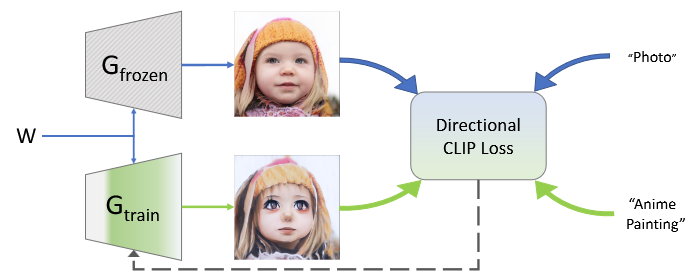

Основные новшества статьи:
- использование в качестве лосса не просто косинусного расстояния между вектором изменяемой картинки и вектором целевого промпта, но косинусного расстояния между векторами от исходного промпта к целевому (ΔT) и от исходной картинки к желаемой (ΔI) в пространстве CLIP (т.н. направленный лосс):

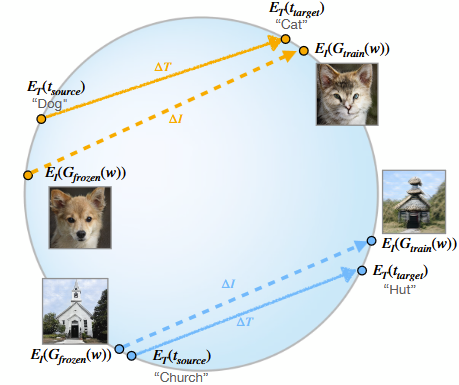

- обучение не всех слоев генератора, а только тех, которые наиболее сильно влияют на результирующую картинку, такие слои определяют по значению градиента для их параметров (loss feedback)

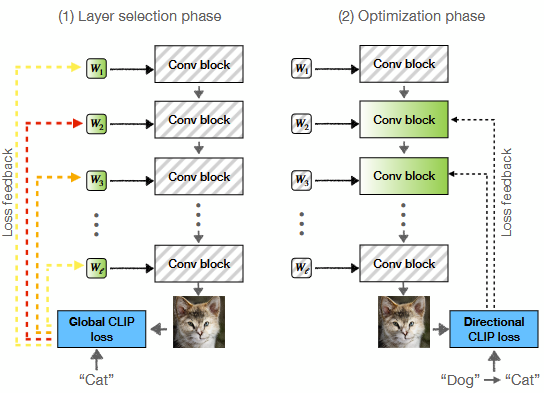

# Подготовка (примерно 5 минут)

In [ ]:
#@title Подготовка

import sys

!pip install -q ftfy regex tqdm gdown
!pip install -q Ninja
!pip install -q git+https://github.com/openai/CLIP.git
# импортирую свой репозиторий
!git clone -q https://github.com/DmitryVeryutin/StyleGAN-NADA-DLS /content/nada_dls
sys.path.append('/content/nada_dls')

from losses import DirectionalCLIPLoss
from losses import GlobalCLIPLoss
from latent_optimizer import LatentOptimizer
from e4e_encoder import e4eEncoder
from model_nada import DomainAdapter

# импортирую орригинальный стайлган2 репо для создания генераторов
!git clone -q https://github.com/rosinality/stylegan2-pytorch.git /content/stylegan2-pytorch
sys.path.append('/content/stylegan2-pytorch')

%cd /content/stylegan2-pytorch
from model import Generator # sg2 repo

# Импорт нужных библиотек
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torchvision.utils import save_image
import clip
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import gc

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# downloads StyleGAN's weights and facial recognition network weights
ids = ['1EM87UquaoQmk17Q8d5kYIAHqu0dkYqdT', '1N0MZSqPRJpLfP4mFQCS14ikrVSe8vQlL']

for file_id in ids:
  downloaded = drive.CreateFile({'id':file_id})
  downloaded.FetchMetadata(fetch_all=True)
  downloaded.GetContentFile(downloaded.metadata['title'])

device = 'cuda' if torch.cuda.is_available() else 'cpu'

file_path = "/content/stylegan2-pytorch/lpips/__init__.py"

# Откроем файл и прочитаем его содержимое
with open(file_path, 'r') as file:
    lines = file.readlines()

# Заменим нужную строку в lpips лоссе для совместимости
with open(file_path, 'w') as file:
    for line in lines:
        # Если в строке есть "compare_ssim", заменим на "structural_similarity"
        if "from skimage.measure import compare_ssim" in line:
            file.write("from skimage.metrics import structural_similarity\n")
        else:
            file.write(line)

print("Замена в lpips выполнена успешно!")

import lpips  # Библиотека для вычисления perceptual loss

# Импорт необходимых библиотек
from google.colab import drive
import math  # Модуль для математических операций
import os  # Модуль для взаимодействия с операционной системой
from torch.nn import functional as F
from tqdm import tqdm
# переключаюсь на репо с продобученным энкодером для инверсии и выравниванием лица
! git clone -q https://github.com/omertov/encoder4editing.git /content/encoder4editing

sys.path.append('/content/encoder4editing')
%cd /content/encoder4editing
file_path = "/content/encoder4editing/utils/alignment.py"

# Откроем файл и прочитаем его содержимое
with open(file_path, 'r') as file:
    lines = file.readlines()

# Заменим нужную строку для совеместимости
with open(file_path, 'w') as file:
    for line in lines:
        # Если в строке есть "compare_ssim", заменим на "structural_similarity"
        if "        img = img.resize(rsize, PIL.Image.ANTIALIAS)" in line:
            file.write("        img = img.resize(rsize, PIL.Image.LANCZOS)\n")
        else:
            file.write(line)

print("Замена в alignment выполнена успешно!")

%matplotlib inline

clip_model, clip_preprocess = clip.load("ViT-B/32", device="cuda")

import gc
gc.collect()
torch.cuda.empty_cache()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 422.8/422.8 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 77.9 MB/s eta 0:00:00
/co

/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Замена в lpips выполнена успешно!
/content/encoder4editing
Замена в alignment выполнена успешно!


100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 61.3MiB/s]


# Дообучение под целевой домен

Параметры:
*   start_prompt - текстовое описание исходной картинки
*   prompt - описание желемого домена
*   num_steps - количество шагов оптимизации
*   layers_to_train - число слоев, которые будут обучаться в ходе оптимизации: от 0 до 18
*   pic_batch - количество изображений, на которых обучается модель
*   pic_sample - количество изображений, на которых происходит валидация
*   global_loss_impact - доля вклада общего лосса при обучении на направленном лоссе (моя модификация, по умолчанию 0)

Рекомендации по выбору числа шагов и слоев для обучения из оригинальной статьи:
*   Изменения стиля и домена ('photo' -> 'sketch') обычно требуют 200-400 итераций. Изменение личности ('person' -> 'taylor swift') - 150-200 итераций. Простым изменениям внутри домена ('face' -> 'smiling face') может хватить и 50.
*    Для сильных изменений ('photo' -> 'sketch') лучше обучать все 18 слоев, для небольших изменений (‘Human’ -> ‘Werewolf’) можно обучать 12 слоев.

Для удобства сравнения результатов с оригиналом я взял такой же сид, как в статье. В качестве метрики качества я взял косинусное расстояние между картинкой и целевым доменом в пространстве CLIP.



Генератор StyleGAN2 загружен.


  0%|          | 0/200 [00:00<?, ?it/s]

inversion_generated_z/Step [0/200], Global_loss: 0.8232421875, Direct_loss: 0.97998046875


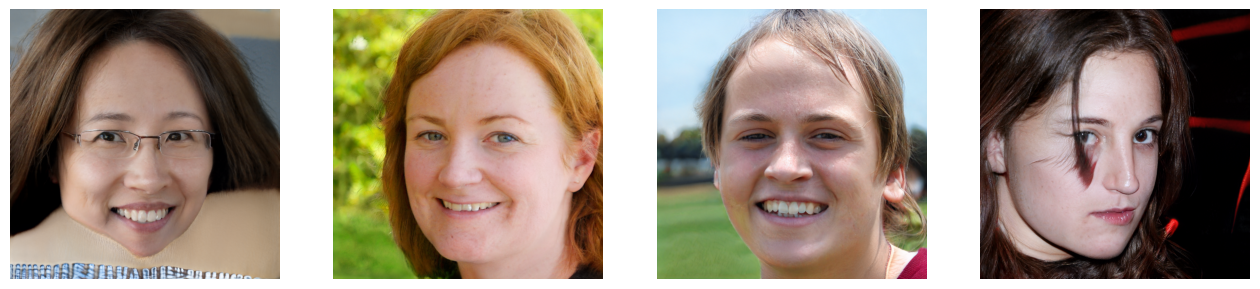

 25%|██▌       | 50/200 [00:53<02:34,  1.03s/it]

inversion_generated_z/Step [50/200], Global_loss: 0.767578125, Direct_loss: 0.82177734375


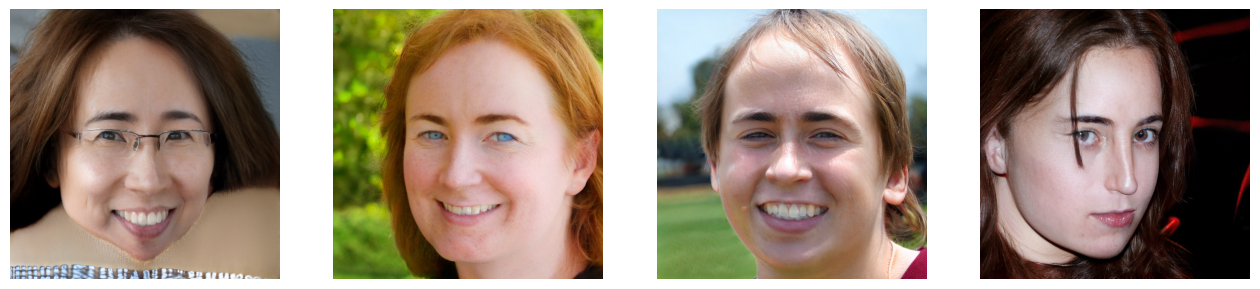

 50%|█████     | 100/200 [01:46<01:44,  1.04s/it]

inversion_generated_z/Step [100/200], Global_loss: 0.72412109375, Direct_loss: 0.7763671875


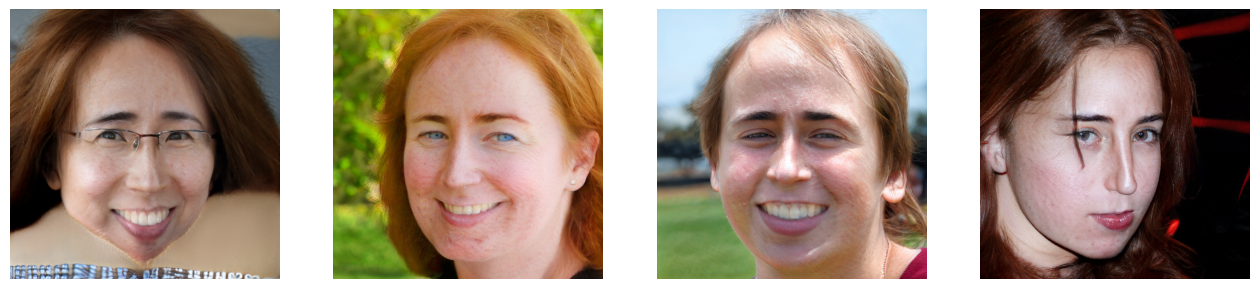

 75%|███████▌  | 150/200 [02:38<00:50,  1.00s/it]

inversion_generated_z/Step [150/200], Global_loss: 0.73876953125, Direct_loss: 0.7490234375


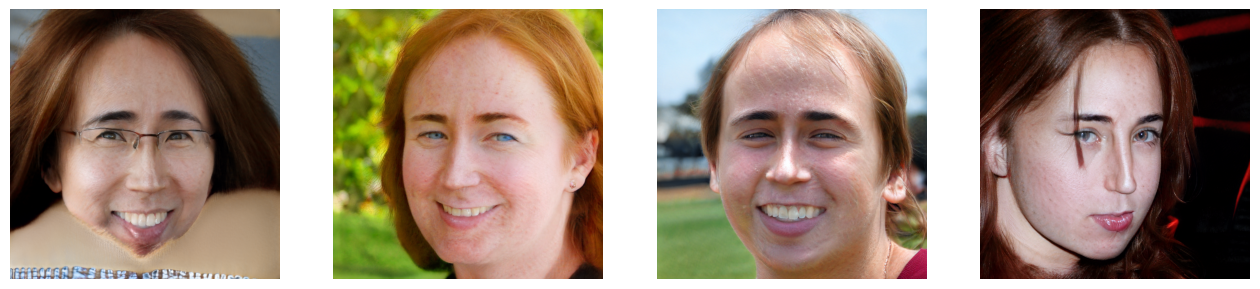

100%|█████████▉| 199/200 [03:29<00:01,  1.04s/it]

inversion_generated_z/Step [199/200], Global_loss: 0.724609375, Direct_loss: 0.771484375


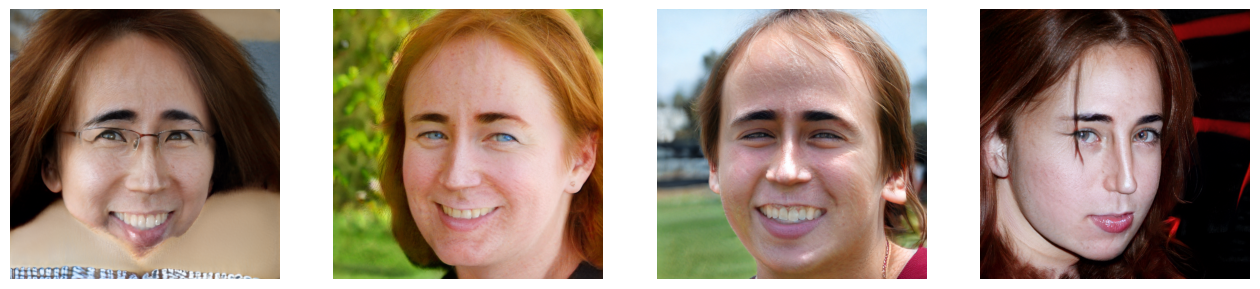

100%|██████████| 200/200 [03:32<00:00,  1.06s/it]


Результаты успешно сохранены в папку /content/encoder4editing с именем sg2_weights_for_adaptation_from_Person_to_Nicolas Cage.pt


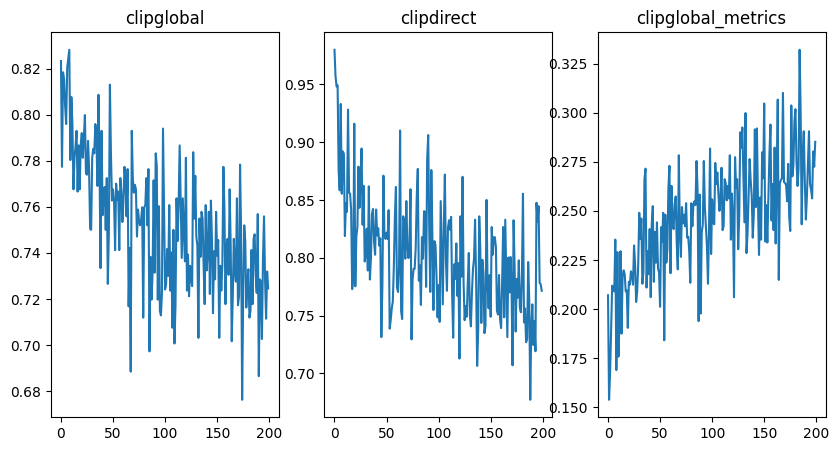

In [ ]:
#@title Дообучение

# Загрузка модели генератора StyleGAN2
latent_dim = 512

generator = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)
fixed_generator = Generator(size=1024, style_dim=latent_dim, n_mlp=8).to(device)

state_dict = torch.load('/content/stylegan2-pytorch/stylegan2-ffhq-config-f.pt', map_location=device)
generator.load_state_dict(state_dict['g_ema'])
fixed_generator.load_state_dict(state_dict['g_ema'])

fixed_generator.eval()
print("Генератор StyleGAN2 загружен.")

# Подготавливаем текстовые промпты стартовой картинки и желаемого результата.
start_prompt = 'Person' #@param {"type": "string"} 'Photo' 'Human'
prompt = 'Nicolas Cage' #@param {"type": "string"} 'Sketch' #"Werewolf" 'Plastic puppet' 'Zombie' 'Cubism' "Nicolas Cage"
num_steps = 200 #@param {"type": "integer"}
layers_to_train = 12 #@param {"type": "integer", "min": 0, "max": 18} 1-18 свертка 1 и в КЗС вынесены из сверток, основных сверток 16, отсюда и 18

pic_batch = 2 #@param {"type": "integer"}
pic_sample = 4 #@param {"type": "integer"}

# для оптимизации сразу токенизирую промпты
start_text_inputs = clip.tokenize(start_prompt).to(device)
text_inputs = clip.tokenize(prompt).to(device)

# Оптимизация для редактирования с помощью CLIP

# Создадим оптимизатор Adam
generator_optimizer = torch.optim.Adam(generator.parameters(), lr=0.002, betas=(0.0, 0.999)) # lr=0.005 and more changes pic more, but changes face shape in a bad way

global_loss_impact = 0 #@param {"type": "number", "min": 0.0, "max": 1.0}
# создадим лоссы и доообучим генератор
clipglobal = GlobalCLIPLoss(stylegan_size=1024, clip_model=clip_model, clip_preprocess=clip_preprocess)
clipdirect = DirectionalCLIPLoss(stylegan_size=1024, global_loss_impact=global_loss_impact, clip_model=clip_model, clip_preprocess=clip_preprocess)

# фиксируем сиды для воспроизводимости результатов
seed = 3 #@param {"type": "integer"}
torch.manual_seed(seed)
np.random.seed(seed)

domain_adapter = DomainAdapter(generator=generator, fixed_generator=fixed_generator,
                 clipglobal=clipglobal, generator_optimizer = generator_optimizer,
                 clipdirect=clipdirect, pic_batch = pic_batch, pic_sample = pic_sample,
                 layers_to_train=layers_to_train, num_steps=num_steps, device=device,
                 text_inputs = text_inputs, start_text_inputs = start_text_inputs)

generator, fixed_generator, losses = domain_adapter()
# сохраним результат и выведем графики лоссов
model_filename = f'sg2_weights_for_adaptation_from_{start_prompt}_to_{prompt}.pt'
torch.save(generator.state_dict(), model_filename)
print(f"Результаты успешно сохранены в папку {'/content/encoder4editing'} с именем {model_filename}")

f, ax = plt.subplots(1, 3, sharex=True, figsize=(10, 5))
i = 0
for key in losses: #'{'clipglobal': [],'clipdirect': [],'clipglobal_metrics': []}'
    y = losses[key] # added item in train loop
    x = [i for i in range(len(y))]

    ax[i].plot(x, y)
    ax[i].set_title(f'{key}')
    i += 1
plt.show()

Результат не такой хороший, как в оргигинальной имплементации, модель явно идет в нужном направлении, но как будто недорабатывает. Это довольно странно, ведь детали реализации, такие как шаг обучения и размеры батчей, у меня такие же, как в статье. Может, причина в деталях реализации лосса, например, в нормализациях?

Я пробовал увеличивать шаг обучения, но при этом форма лица на картинках сильно искажалась. Также я пробовал подмешивать к направленному лоссу немного глобального, чтобы повысить метрику качества - косинусное расстояние между картинками. Однако результаты это не улучшило, поэтому оставил вклад глобального лосса в направленный нулевым, однако для удобства вывел его в параметры обучения.

# Преобразование сгенерированных картинок

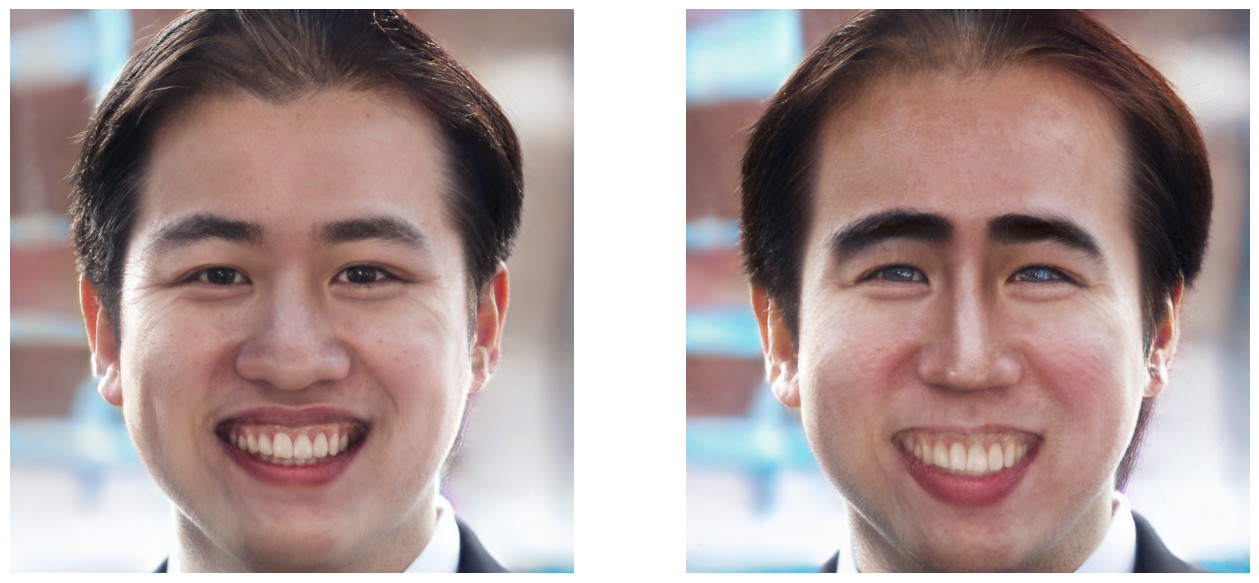

CLIP cosine simularity target text - original picture: 0.20751953125
CLIP cosine simularity target text - adapted picture: 0.3193359375
Результаты успешно сохранены в папку Adapted_pics с именем Gen_image_adapted_from_Person_to_Nicolas Cage


In [ ]:
#@title Преобразование сгенерированной картинки
from utils.common import tensor2im
%matplotlib inline

gen_latent = fixed_generator.style(torch.randn(1, 512, device=device))
generator.eval()
with torch.no_grad():
  gen_images = [fixed_generator([gen_latent], input_is_latent=True)[0], generator([gen_latent], input_is_latent=True)[0]]
  clipglobal_orig = 1 - clipglobal(gen_images[0], text_inputs)
  clipglobal_adapt = 1 - clipglobal(gen_images[1], text_inputs)

fig, axs = plt.subplots(1, 2, figsize=(16, 32))  # Создание подграфиков для визуализации
for i in range(2):
    axs[i].imshow((gen_images[i][0].cpu().detach().clip(-1,1).permute(1, 2, 0) + 1) / 2)
    axs[i].axis('off')  # Отключение осей
plt.show()

print('CLIP cosine simularity target text - original picture:', clipglobal_orig.item())
print('CLIP cosine simularity target text - adapted picture:', clipglobal_adapt.item())

pic_size = (1024, 1024)

gen_im, gen_ad_im = tensor2im(gen_images[0].squeeze(0)), tensor2im(gen_images[1].squeeze(0))

res = np.concatenate([np.array(gen_im.resize(pic_size)),
                              np.array(gen_ad_im.resize(pic_size))], axis=1)
res = Image.fromarray(res)

# Сохранение результатов
save_dir = 'Adapted_pics'
filename = f"Gen_image_adapted_from_{start_prompt}_to_{prompt}"

# Проверка, что создана папка для сохранения результатов
os.makedirs(save_dir, exist_ok=True)

# Save the image to a .png file.
image_path = os.path.join(save_dir, filename + ".png")
res.save(image_path)

print(f"Результаты успешно сохранены в папку {save_dir} с именем {filename}")

# Инвертирование реальных картинок

При выполнении кода будет создана папка "/content/folder_for_image", в которую по запросу нужно подгрузить картинку в формате jpg или png. Поддерживается инвертирование только одной картинки. Параметр invertor_type позволяет задать способ инверсии.

Доступно два варианта:
- инверсия при помощи прямой оптимизации латента (latent_opt)
- использование предобученного энкодера (encoder4editing).

Прямая оптимизация дает наиболее близкий к оригиналу результат, но картинка получается мутноватой и качество адаптации домена с этой картинкой тоже не самое лучшее. Предобученный энкодер дает более качественный результат и при инверсии, и при адаптации, но может искажать детали изображения, а также выдает картинку не очень высокого разрешения, всего 256х256. Я тестировал этот энкодер на своем фотопортрете, и он делал меня другим человеком, пусть и похожим в общих чертах.

Please upload an image to the folder: /content/folder_for_image
File uploaded: /content/folder_for_image/ian-dooley-d1UPkiFd04A-unsplash.jpg
Aligned image has shape: (256, 256)
Loading e4e over the pSp framework from checkpoint: /content/encoder4editing/e4e_ffhq_encode.pt
Model successfully loaded!
Inference took 0.1213 seconds.


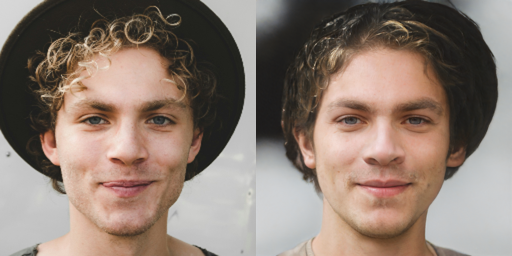

Результаты успешно сохранены в папку optimization_results_e4e с именем real_image_w+_optimization_e4e


In [ ]:
#@title Модуль для инвертирования реальных картинок

gc.collect()
torch.cuda.empty_cache()

folder_path = "/content/folder_for_image"
# Проверка, что создана папка для сохранения результатов
os.makedirs(folder_path, exist_ok=True)
files = os.listdir(folder_path)

import time
# модуль с запросом на загрузку картинки и ожиданием файла
print(f"Please upload an image to the folder: {folder_path}")
# Wait until a file appears
while True:
    files = [f for f in os.listdir(folder_path) if f.endswith(('.jpg', '.png'))]
    if files:
        image_path = os.path.join(folder_path, files[0])
        print(f"File uploaded: {image_path}")
        break
    time.sleep(1)

invertor_type = 'encoder4editing' #@param ['encoder4editing', 'latent opt']
pic_size = (1024, 1024)

if invertor_type == 'encoder4editing':
    result_path = '/content/encoder4editing/optimization_results_e4e/real_image_w+_optimization_e4e.pt'
elif invertor_type == 'latent opt':
    result_path = '/content/encoder4editing/optimization_results_lat_opt/real_image_w+_optimization_lat_opt.pt'

# Загружаем и отображаем изображение
from PIL import Image

original_image = Image.open(image_path)
original_image = original_image.convert("RGB")  # Преобразуем изображение в RGB формат

import dlib
from utils.alignment import align_face  # Функция для выравнивания лица

# Загружаем модель для определения ключевых точек лица - понадобится нам для выравнивания
if 'shape_predictor_68_face_landmarks.dat' not in os.listdir():
    !wget http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2  # Скачиваем архив с моделью
    !bzip2 -dk shape_predictor_68_face_landmarks.dat.bz2  # Распаковываем архив

# Задаем размер изображения для изменения
resize_dims = pic_size


def run_alignment(image_path):
  """Выравнивает лицо на изображении, используя dlib.

  Args:
      image_path: Путь к файлу изображения.

  Returns:
      Выровненное изображение в формате PIL.Image.
  """
  import dlib
  from utils.alignment import align_face  # Функция для выравнивания лица
  predictor = dlib.shape_predictor("shape_predictor_68_face_landmarks.dat")
  aligned_image = align_face(filepath=image_path, predictor=predictor)
  print("Aligned image has shape: {}".format(aligned_image.size))
  return aligned_image  # Возвращаем выровненное изображение


# Выравниваем лицо
input_image = run_alignment(image_path)
input_image = input_image.resize(resize_dims)

# делаем инверсию с сохранением латентных векторов и полученных картинок
if invertor_type == 'latent opt':
    # Загрузка Perceptual Loss (LPIPS)
    perceptual_loss = lpips.PerceptualLoss(
          model="net-lin", net="alex", use_gpu=device
      )
    print("LPIPS загружен.")
    #print("Генератор успешно загружен.")

    invertor = LatentOptimizer(fixed_generator=fixed_generator,
                               pic_size=(1024, 1024),
                               perceptual_loss=perceptual_loss,
                               device=device)
    invertor(input_image, num_steps_w=1000, #2000
                alpha=5,  # Коэффициент для перцептивной потери
                beta=1e5)

if invertor_type == 'encoder4editing':
    from models.psp import pSp  # Импортируем модель pSp
    from argparse import Namespace
    model_path = '/content/encoder4editing/e4e_ffhq_encode.pt'  # Путь к весам энкодера

    if not os.path.isfile(model_path):
        # Authenticate and create the PyDrive client.
        auth.authenticate_user()
        gauth = GoogleAuth()
        gauth.credentials = GoogleCredentials.get_application_default()
        drive = GoogleDrive(gauth)

        # downloads encoders's weights and facial recognition network weights
        ids = ['1cUv_reLE6k3604or78EranS7XzuVMWeO']
        for file_id in ids:
            downloaded = drive.CreateFile({'id':file_id})
            downloaded.FetchMetadata(fetch_all=True)
            downloaded.GetContentFile(downloaded.metadata['title'])

    ckpt = torch.load(model_path, map_location='cpu')
    opts = ckpt['opts']

    opts['checkpoint_path'] = model_path
    opts = Namespace(**opts)
    net = pSp(opts)
    net.eval()
    net.to(device)
    print('Model successfully loaded!')

    # чтобы убедиться, что инверсия ничего не исказила
    # делаем из латента картинку не сетью из е4е, а нашим сг2 генератором
    invertor = e4eEncoder(net=net, fixed_generator=fixed_generator, device=device)
    invertor(input_image)

# Преобразование реальных картинок

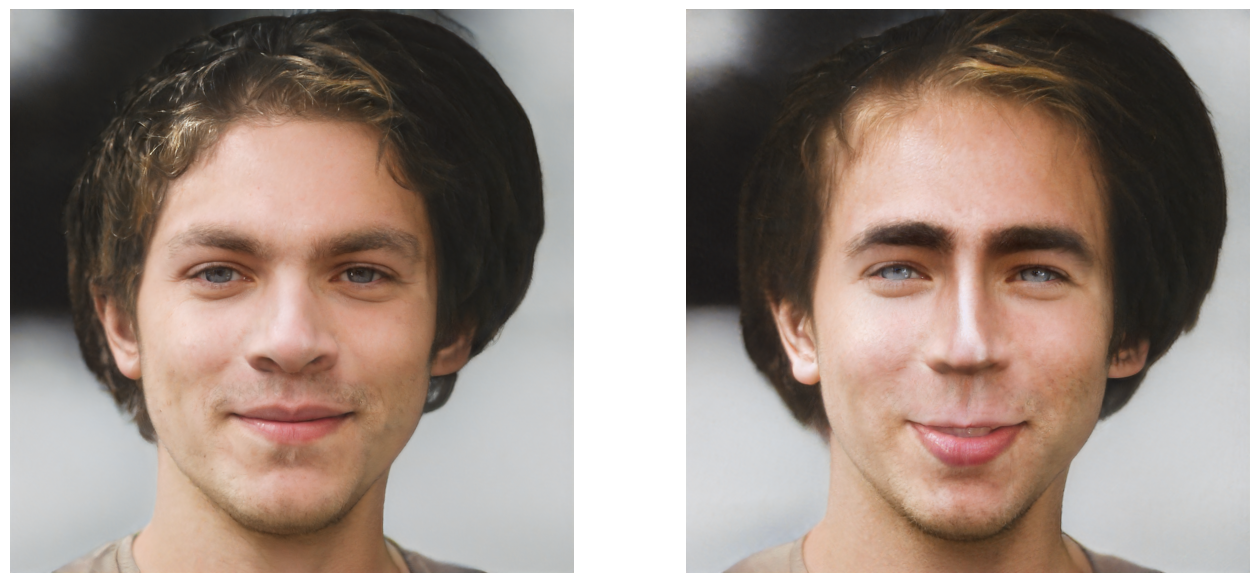

CLIP cosine simularity target text - original picture: 0.14599609375
CLIP cosine simularity target text - adapted picture: 0.3154296875
Результаты успешно сохранены в папку Adapted_pics с именем Real_image_adapted_from_Person_to_Nicolas Cage


In [ ]:
#@title Преобразование реальной картинки

gc.collect()
torch.cuda.empty_cache()
%matplotlib inline

real_latent = torch.load(result_path, map_location=device)
generator.eval()
with torch.no_grad():
  real_images = [fixed_generator([real_latent], input_is_latent=True)[0], generator([real_latent], input_is_latent=True)[0]]

  clipglobal_orig = 1 - clipglobal(real_images[0], text_inputs)
  clipglobal_adapt = 1 - clipglobal(real_images[1], text_inputs)

fig, axs = plt.subplots(1, 2, figsize=(16, 32))  # Создание подграфиков для визуализации
for i in range(2):
    axs[i].imshow((real_images[i][0].cpu().detach().clip(-1,1).permute(1, 2, 0) + 1) / 2)
    axs[i].axis('off')  # Отключение осей
plt.show()

print('CLIP cosine simularity target text - original picture:', clipglobal_orig.item())
print('CLIP cosine simularity target text - adapted picture:', clipglobal_adapt.item())

pic_size = (1024, 1024)

real_im, real_ad_im = tensor2im(real_images[0].squeeze(0)), tensor2im(real_images[1].squeeze(0))

res = np.concatenate([np.array(real_im.resize(pic_size)),
                              np.array(real_ad_im.resize(pic_size))], axis=1)
res = Image.fromarray(res)

# Сохранение результатов
save_dir = 'Adapted_pics'
filename = f"Real_image_adapted_from_{start_prompt}_to_{prompt}"

# Проверка, что создана папка для сохранения результатов
os.makedirs(save_dir, exist_ok=True)

# Save the image to a .png file.
image_path = os.path.join(save_dir, filename + ".png")
res.save(image_path)

print(f"Результаты успешно сохранены в папку {save_dir} с именем {filename}")